# Section 1
Compare Dice Coefficient using :
1. Binary Thresholding with a fixed threshold.
2. Otsu's Method.
3. Optimized thresholding using the Dice Coefficient.
4.
Visualize the results by comparison of the original image, ground truth mask, and the results from each thresholding method.

P.S: Use skimage library

Input Image

In [ ]:
!gdown "1sWYKuwLg_1nFylJ1h9Xpjr5zy-1-BwcN"  # Input image

Downloading...
From: https://drive.google.com/uc?id=1sWYKuwLg_1nFylJ1h9Xpjr5zy-1-BwcN
To: /content/LAB05 IMG1.png
100% 61.6k/61.6k [00:00<00:00, 20.9MB/s]


Ground Truth Image


In [ ]:
!gdown "15jipoft8qFVghFrLVlWTDJmvtZTKuVeB" # Ground Truth

Downloading...
From: https://drive.google.com/uc?id=15jipoft8qFVghFrLVlWTDJmvtZTKuVeB
To: /content/LAB05 IMG2.png
100% 15.4k/15.4k [00:00<00:00, 30.7MB/s]


In [3]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

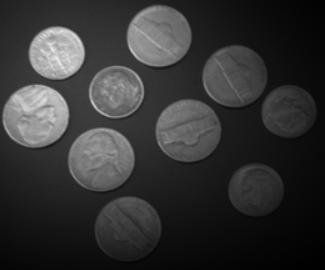

In [ ]:
# Load and display the input image
# Answer your code here
input_img = cv.imread('/content/LAB05 IMG1.png', cv.IMREAD_GRAYSCALE)
cv2_imshow(input_img)

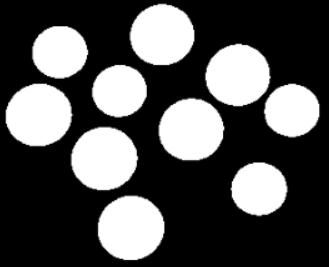

In [ ]:
# Load and display the ground truth image
# Answer your code here
ground_truth_path = '/content/LAB05 IMG2.png'
ground_truth = cv.imread(ground_truth_path, cv.IMREAD_GRAYSCALE)
cv2_imshow(ground_truth)

## Binary Thresholding with fixed threshold

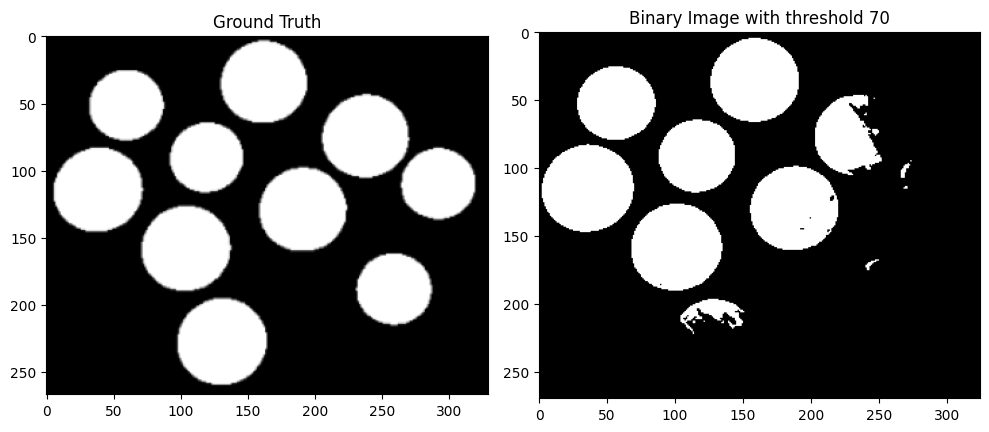

In [ ]:
imageG = io.imread('/content/LAB05 IMG1.png', as_gray=True)  # Load as grayscale
image = (imageG * 255).astype(np.uint8)   # Convert to integer range 0-255 from normalized [0, 1]

# Set the threshold value
threshold_value = 70

# Perform binarization
# np.where(condition, x, y): If condition is True, returns x; if False, returns y.
binary_image = np.where(image >= threshold_value, 255, 0).astype(np.uint8)


# Plotting
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Ground Truth")
plt.imshow(ground_truth, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Binary Image with threshold 70')
plt.imshow(binary_image, cmap='gray')

plt.tight_layout()
plt.show()

## Otsu's method

Otsu's threshold: 80


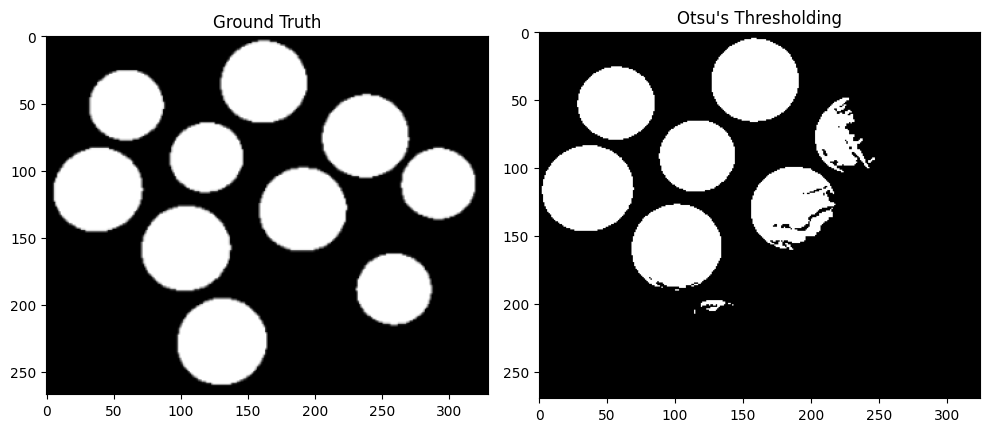

In [ ]:
# Answer your code here
from skimage.filters import threshold_otsu

otsu_threshold = threshold_otsu(input_img)
print(f"Otsu's threshold: {otsu_threshold}")

# Apply thresholding
otsu_img = input_img > otsu_threshold

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Ground Truth")
plt.imshow(ground_truth, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Otsu's Thresholding")
plt.imshow(otsu_img, cmap='gray')

plt.tight_layout()
plt.show()

## Mutil Otsu

Thresholds: [36 97]


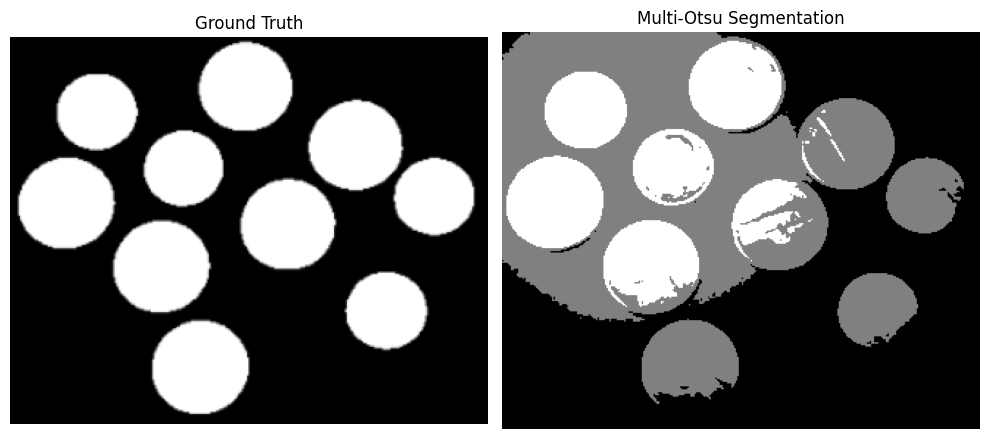

In [ ]:
from skimage.filters import threshold_multiotsu

# Calculate multiple thresholds using the Multi-Otsu method
thresholds = threshold_multiotsu(input_img, classes=3)
print(f"Thresholds: {thresholds}")

# Apply multi-threshold segmentation
# np.digitize() takes a pixel and divides it into bins
regions = np.digitize(image, bins=thresholds) # Categorize pixel values into classes based on the thresholds

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Ground Truth")
plt.imshow(ground_truth, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Multi-Otsu Segmentation")
plt.imshow(regions, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

## Optimized thresholding using the Dice Coefficient.

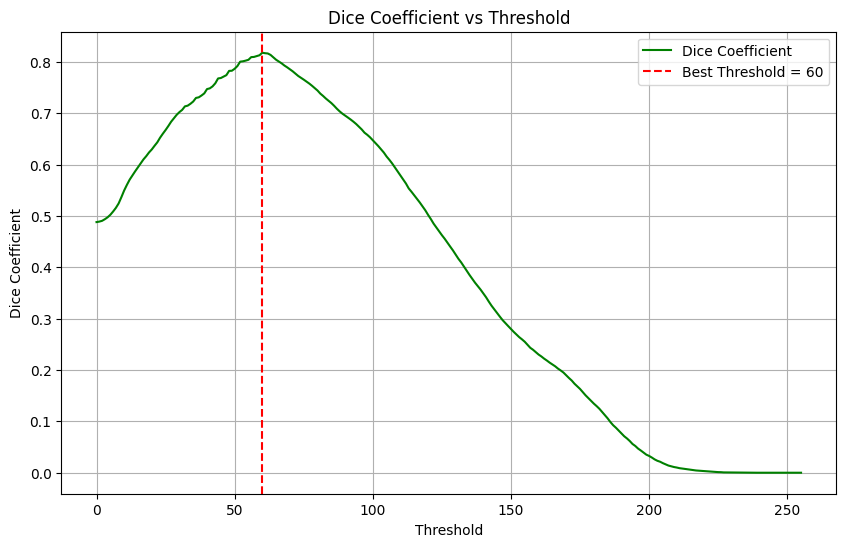

Best Threshold: 60
Maximum Dice Coefficient: 0.8180


In [ ]:
# Step 1: Load the input image and ground truth using OpenCV
image_path = '/content/LAB05 IMG1.png'
ground_truth_path = '/content/LAB05 IMG2.png'

# Load input image as grayscale
image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

# Load ground truth and resize it to match input image size
ground_truth = cv.imread(ground_truth_path, cv.IMREAD_GRAYSCALE)
ground_truth_resized = cv.resize(ground_truth, (image.shape[1], image.shape[0]))  # Match input size
ground_truth_binary = (ground_truth_resized > 128).astype(np.uint8)  # Ensure binary (0 or 1)

# Step 2: Initialize variables to store best threshold and maximum Dice coefficient
best_threshold = 0.2
max_dice = 0.2
dice_values = []  # Store Dice coefficient for each threshold

# Step 3: Iterate through all threshold values (0-255)
for threshold in range(256):
    # Perform binary thresholding using OpenCV
    _, t_image = cv.threshold(image, threshold, 1, cv.THRESH_BINARY)  # Binary segmentation (0 or 1)

    # Calculate Dice coefficient
    intersection = np.sum(t_image * ground_truth_binary)
    dice_coefficient = (2. * intersection) / (np.sum(t_image) + np.sum(ground_truth_binary) + 1e-6)
    dice_values.append(dice_coefficient)  # Store Dice coefficient

    # Update best threshold if current Dice coefficient is greater
    if dice_coefficient > max_dice:
        max_dice = dice_coefficient
        best_threshold = threshold

# Step 4: Visualize the results
plt.figure(figsize=(10, 6))

# Plot Dice coefficient as a function of threshold
plt.plot(range(256), dice_values, label="Dice Coefficient", color="green")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best Threshold = {best_threshold}")
plt.title("Dice Coefficient vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid()
plt.show()

# Step 5: Print the best threshold and its corresponding Dice coefficient
print(f"Best Threshold: {best_threshold}")
print(f"Maximum Dice Coefficient: {max_dice:.4f}")


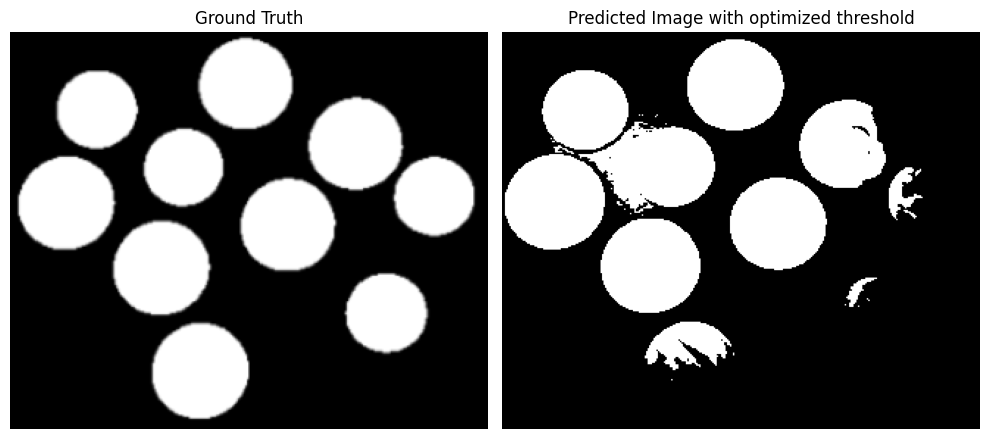

In [ ]:
from skimage import io, transform

# Step 1: Load the input image and preprocess it
image_path = '/content/LAB05 IMG1.png'
image = io.imread(image_path, as_gray=True)  # Load as grayscale (normalized to [0, 1])
image = (image * 255).astype(np.uint8)  # Convert to 8-bit grayscale (0-255)

# Step 2: Set a threshold value and perform binary thresholding
threshold_value = 60
Opt_image = (image >= threshold_value).astype(np.uint8)  # Binary segmentation (0 or 1)

# Step 3: Load and preprocess the ground truth
ground_truth_path = '/content/LAB05 IMG2.png'
ground_truth = io.imread(ground_truth_path, as_gray=True)  # Load as grayscale
ground_truth = transform.resize(ground_truth, image.shape, mode='reflect', anti_aliasing=False) # reflect： image edges reflects as mirror to avoid artifacts at the edges. anti_aliasing: avoid blur, maintain sharpness
ground_truth_binary = (ground_truth > 0.5).astype(np.uint8)  # Convert to binary (threshold = 0.5 for normalized images)

# Step 5: Visualize the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Ground Truth")
plt.imshow(ground_truth, cmap='gray')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Predicted Image with optimized threshold")
plt.imshow(Opt_image, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


## Visualize

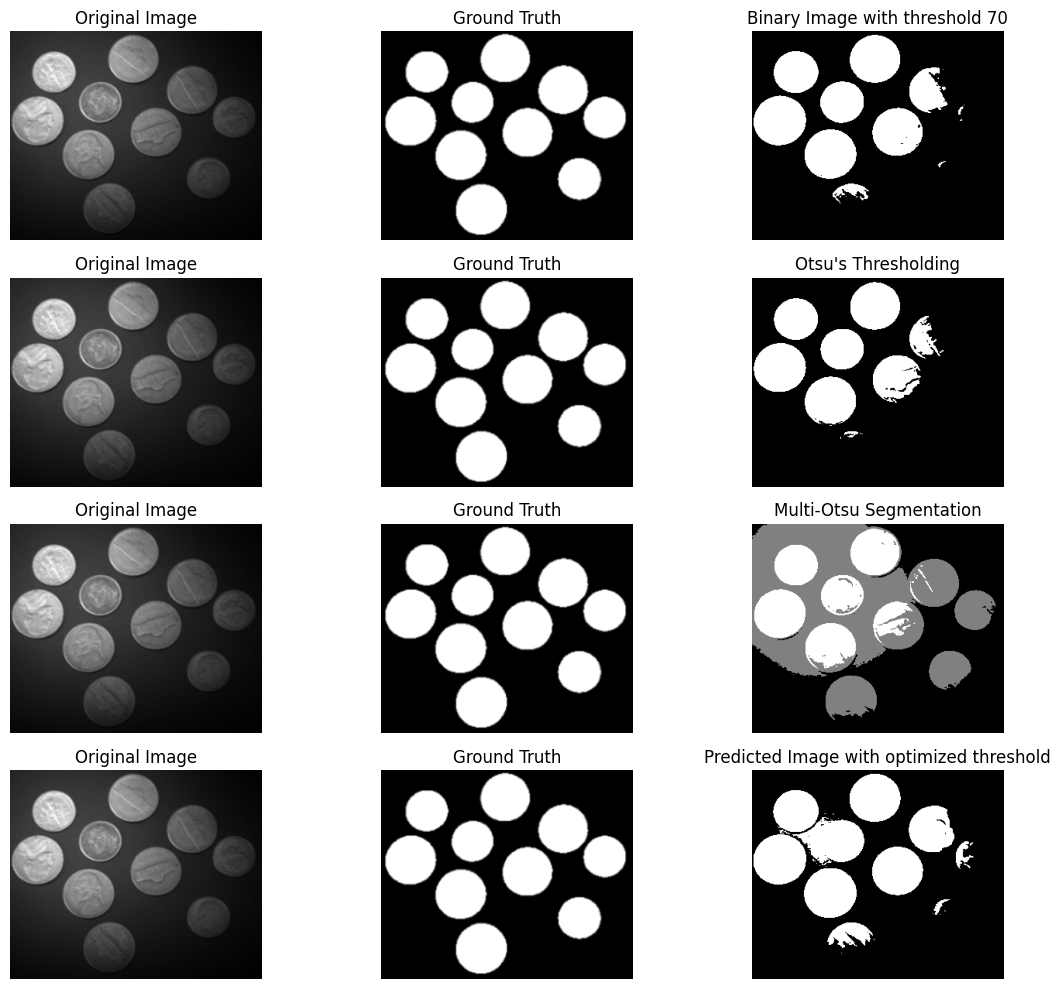

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(4, 3, 1)
plt.title("Original Image")
plt.imshow(input_img, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 2)
plt.title("Ground Truth")
plt.imshow(ground_truth, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 3)
plt.title('Binary Image with threshold 70')
plt.imshow(binary_image, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 4)
plt.title("Original Image")
plt.imshow(input_img, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 5)
plt.title("Ground Truth")
plt.imshow(ground_truth, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 6)
plt.title("Otsu's Thresholding")
plt.imshow(otsu_img, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 7)
plt.title("Original Image")
plt.imshow(input_img, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 8)
plt.title("Ground Truth")
plt.imshow(ground_truth, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 9)
plt.title("Multi-Otsu Segmentation")
plt.imshow(regions, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 10)
plt.title("Original Image")
plt.imshow(input_img, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 11)
plt.title("Ground Truth")
plt.imshow(ground_truth, cmap='gray')
plt.axis("off")

plt.subplot(4, 3, 12)
plt.title("Predicted Image with optimized threshold")
plt.imshow(Opt_image, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


# Section 2
Image Clustering
1. Use the given image and try clustering with 3 different k.
2. Compare and display the results.
3. In which scenario, small k or large k, do the dogs in the image retain the most visual detail?

P.S: Use OpenCV library

In [ ]:
!gdown "1VwgQxqmhhZTCRqI77kkS6cVRunBzZdsa" # Input image for clustering

Downloading...
From: https://drive.google.com/uc?id=1VwgQxqmhhZTCRqI77kkS6cVRunBzZdsa
To: /content/LAB 05 shiba.jpg
100% 99.2k/99.2k [00:00<00:00, 103MB/s]


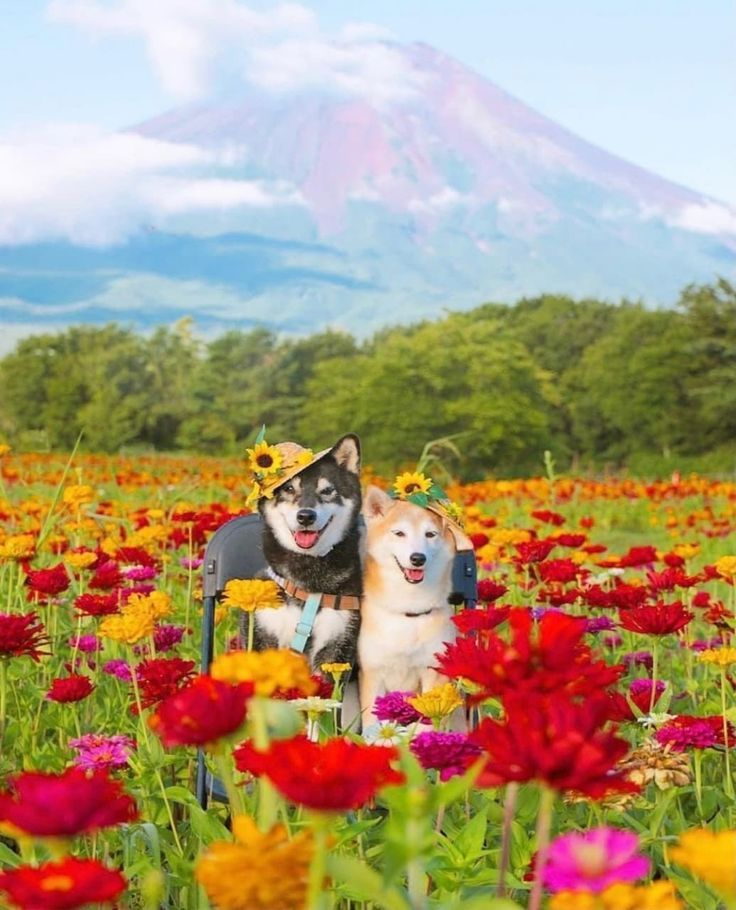

In [ ]:
# Answer your code here
from sklearn.cluster import KMeans

# Load the image
shiba = cv.imread('/content/LAB 05 shiba.jpg', cv.IMREAD_COLOR)
cv2_imshow(shiba)
shiba = cv.cvtColor(shiba, cv.COLOR_BGR2RGB)

<ipython-input-14-d774b7dfb06c>:12: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(k_values, inertia, 'o-', label='Inertia', marker='o')


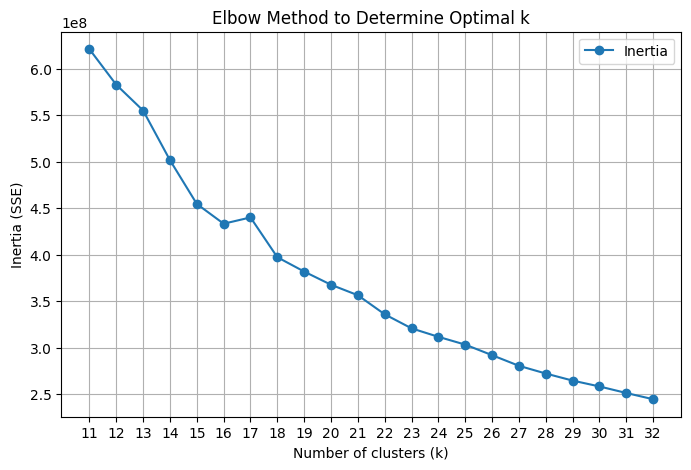

In [ ]:
# Initialize a list to store inertia values
shibapixels = shiba.reshape(-1, 3)  # Flatten the image into a 2D array of pixels
inertia = [] # compactness
k_values = range(11, 33)  # Range of cluster numbers from 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(shibapixels) # Fit the KMeans model on the pixel
    inertia.append(kmeans.inertia_)  # save Inertia

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, 'o-', label='Inertia', marker='o')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

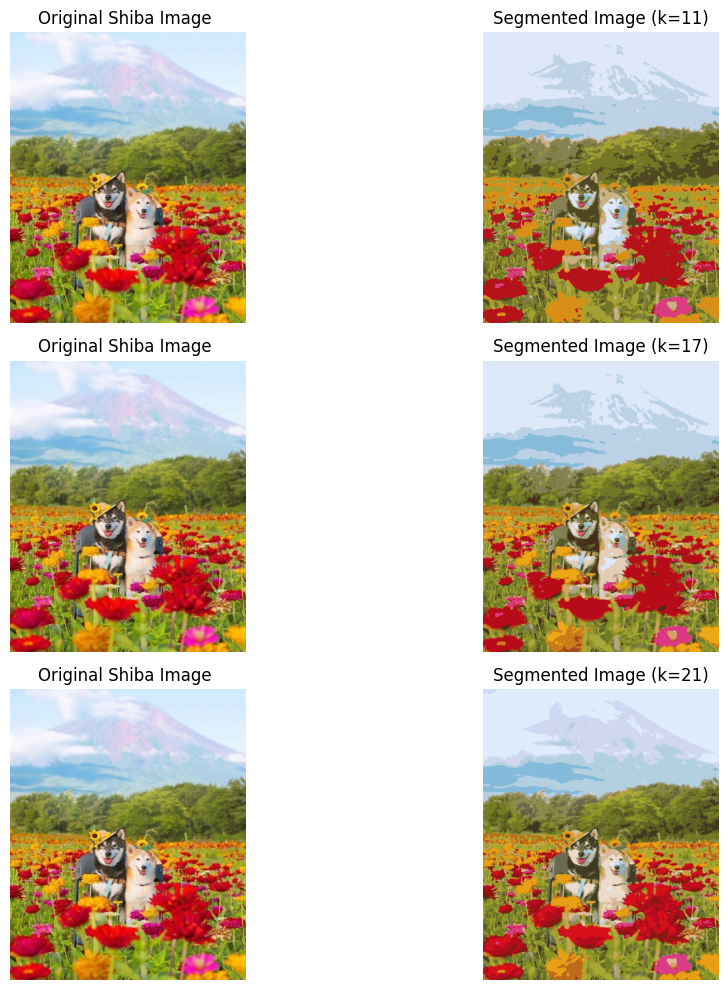

In [ ]:
# k values
k = [11, 17, 21]

# Create subplots
fig, axes = plt.subplots(len(k), 2, figsize=(12, 10))

for i in range(len(k)):
    # Apply K-Means
    kmeans = KMeans(n_clusters=k[i], random_state=0).fit(shibapixels)

    # Map cluster centers to pixels
    segmented_pixels = kmeans.cluster_centers_[kmeans.labels_]
    segmented_image = segmented_pixels.reshape(shiba.shape).astype('uint8')

    # Display images in subplots
    axes[i, 0].imshow(shiba)
    axes[i, 0].set_title(f"Original Shiba Image ")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(segmented_image)
    axes[i, 1].set_title(f"Segmented Image (k={k[i]})")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## In which scenario, small k or large k, do the dogs in the image retain the most visual detail?

Large K (with 21 centroids) retains the most visual detail compared to the K I've selected.

# Section 3

Binary image processing (Basic operators)


> Data that you'll use in this section is "old text paragraph image" and implement to solve each problem to get result with scikit-image libraries.


1.   In image there has some alphabets which missing and faded so you need to make whole paragraph more clear and easy to read than original image.



In [1]:
#import data
!gdown 11WNV3Yr6hZNpRVF4ftNaNF8DYyVlWJlX

Downloading...
From: https://drive.google.com/uc?id=11WNV3Yr6hZNpRVF4ftNaNF8DYyVlWJlX
To: /content/OldText.png
100% 148k/148k [00:00<00:00, 6.92MB/s]


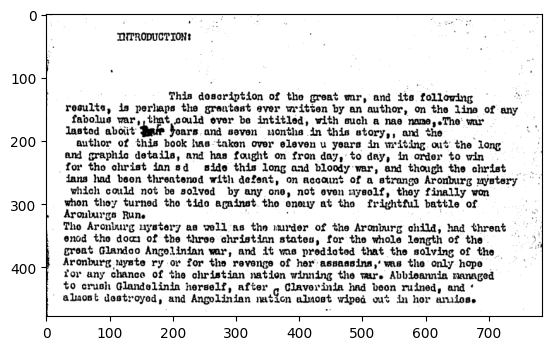

In [5]:
# Answer your code here
# Import libraries
from skimage import morphology
# Load and display the input image
txt = io.imread('/content/OldText.png', as_gray=True)
plt.imshow(txt, cmap='gray')


# Erosion

### Define structure element

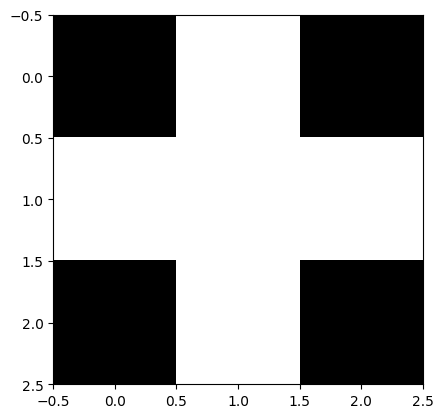

In [ ]:
structuring_element = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
], dtype=np.uint8)

plt.imshow(structuring_element, cmap='gray', vmin=0, vmax=1)

### Perform erosion

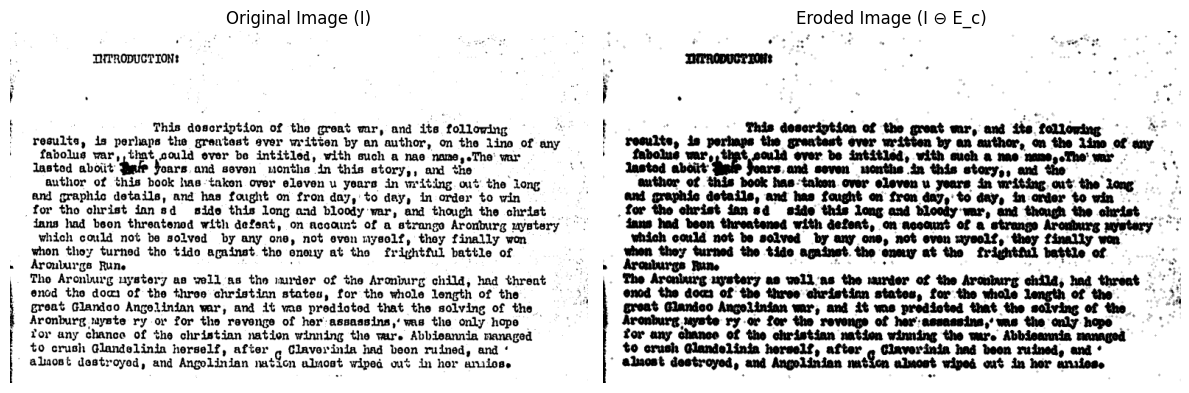

In [ ]:
# Perform erosion
eroded_image = morphology.erosion(txt, structuring_element)

# Step 5: Visualize the results
plt.figure(figsize=(12, 4))

# Original binary image
plt.subplot(1, 2, 1)
plt.imshow(txt, cmap='gray', vmin=0, vmax=1)
plt.title('Original Image (I)')
plt.axis('off')

# Eroded image
plt.subplot(1, 2, 2)
plt.imshow(eroded_image, cmap='gray', vmin=0, vmax=1)
plt.title('Eroded Image (I ⊖ E_c)')
plt.axis('off')

plt.tight_layout()
plt.show()


2. If you can see background of text image is having some noise. To make our background clear you need to remove noises as much as possible.

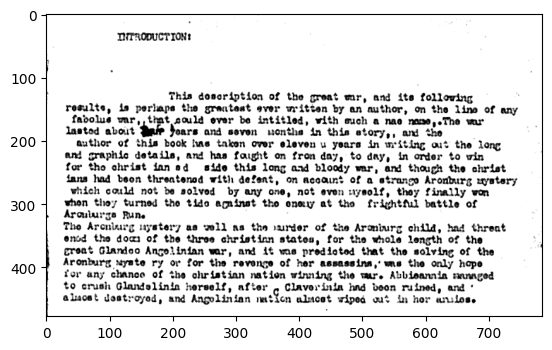

In [6]:
# Answer your code here
from skimage.filters import median
median_txt = median(txt)
plt.imshow(median_txt, cmap='gray')

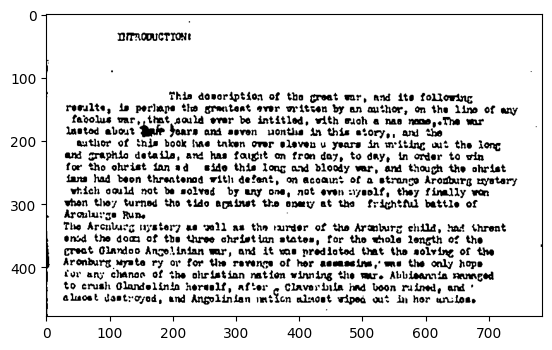

In [7]:
from skimage.filters import threshold_otsu
threshold_value = threshold_otsu(median_txt)
binary_txt = median_txt > threshold_value

plt.imshow(binary_txt, cmap='gray')

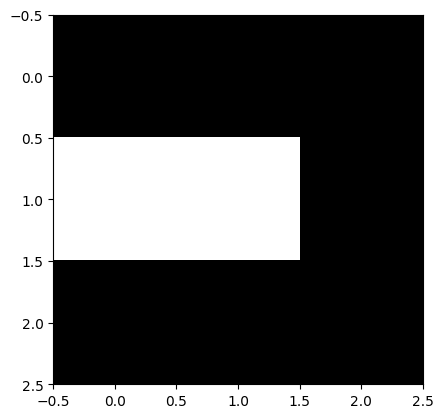

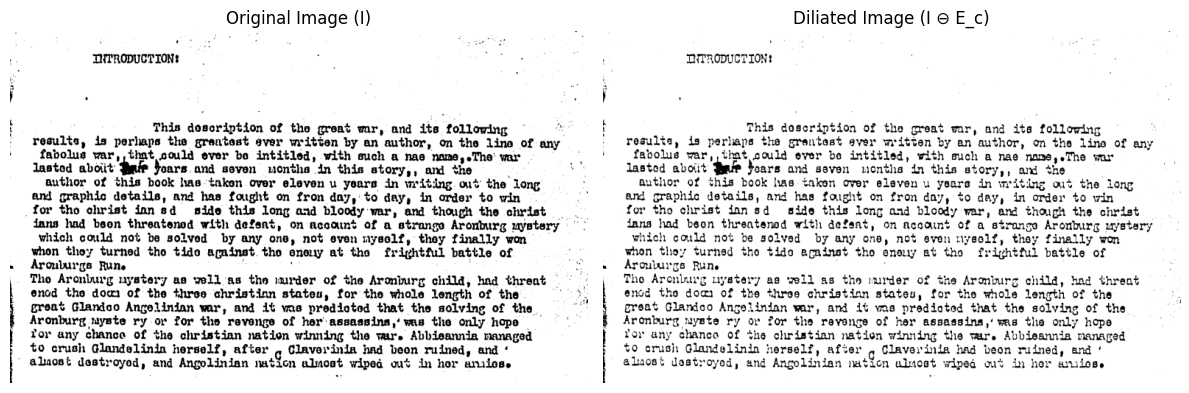

In [12]:
new_structuring_element = np.array([
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
], dtype=np.uint8)

plt.imshow(new_structuring_element, cmap='gray', vmin=0, vmax=1)

# Perform Diliation
Diliated_image = morphology.dilation(txt, new_structuring_element)

#  Visualize the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(txt, cmap='gray', vmin=0, vmax=1)
plt.title('Original Image (I)')
plt.axis('off')

# Diliated image
plt.subplot(1, 2, 2)
plt.imshow(Diliated_image, cmap='gray', vmin=0, vmax=1)
plt.title('Diliated Image (I ⊖ E_c)')
plt.axis('off')

plt.tight_layout()
plt.show()


# Section 4

Binary image processing (Measurement)


> Data that you'll use in this section is "Mitosis cells" and implement to solve each prblem to get result with scikit-image libraries.


1.   Please show this following details of


*   Show area of objects.
*   Create bounding box cover each objects.
*   Show centroid of each objects.
*   Show eccentricity of each objects.
*   Show solidity of each objects.





In [ ]:
import skimage.io as io

Downloading...
From: https://drive.google.com/uc?id=1_mCcNuUPuSPUew0T-EmoTZBRNcOJ0jDM
To: /content/mitosis_mod.tif
100% 5.16k/5.16k [00:00<00:00, 15.2MB/s]


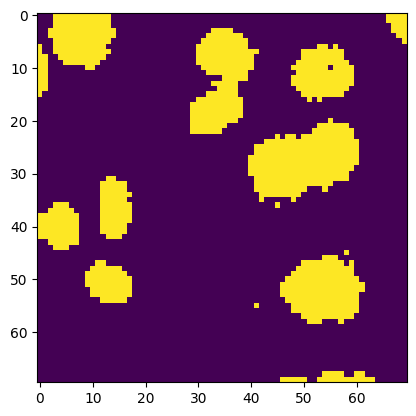

In [ ]:
#import data
!gdown 1_mCcNuUPuSPUew0T-EmoTZBRNcOJ0jDM

image_path = '/content/mitosis_mod.tif'
image_cells = io.imread(image_path, as_gray=True)
image_cells_binary = image_cells > 65
plt.imshow(image_cells_binary)

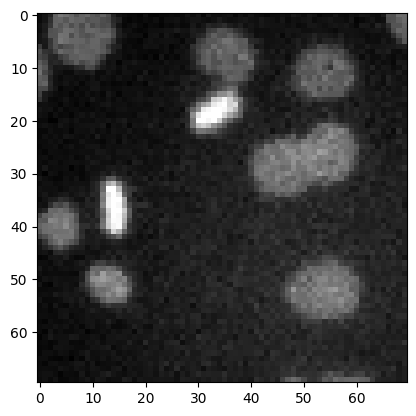

In [ ]:
plt.imshow(image_cells, cmap='gray')

## Area of objects

Text(0.5, 1.0, 'Areas of Objects in Binary Image')

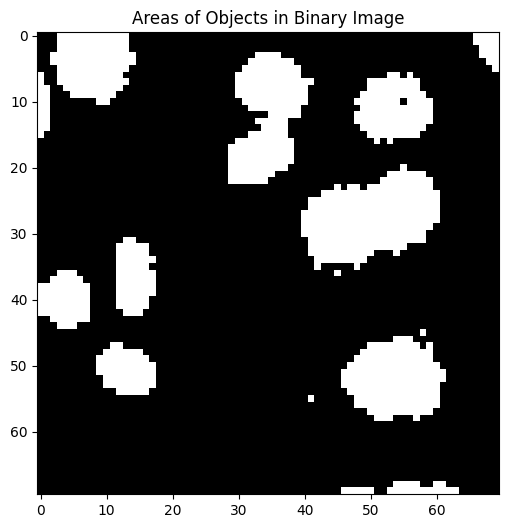

In [ ]:
# Answer your code here
from skimage.measure import label, regionprops

# Label connected regions in the binary image
labeled_image = label(image_cells_binary, connectivity=2)

regions = regionprops(labeled_image)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray', interpolation='none')
ax.set_title('Areas of Objects in Binary Image')

In [ ]:
print("Areas of objects:")
for i, region in enumerate(regions, start=1):
    print(f"Object {i}: Area = {region.area}")

Areas of objects:
Object 1: Area = 109.0
Object 2: Area = 17.0
Object 3: Area = 163.0
Object 4: Area = 17.0
Object 5: Area = 95.0
Object 6: Area = 221.0
Object 7: Area = 60.0
Object 8: Area = 57.0
Object 9: Area = 1.0
Object 10: Area = 1.0
Object 11: Area = 150.0
Object 12: Area = 55.0
Object 13: Area = 1.0
Object 14: Area = 17.0
Object 15: Area = 5.0


## Bounding box

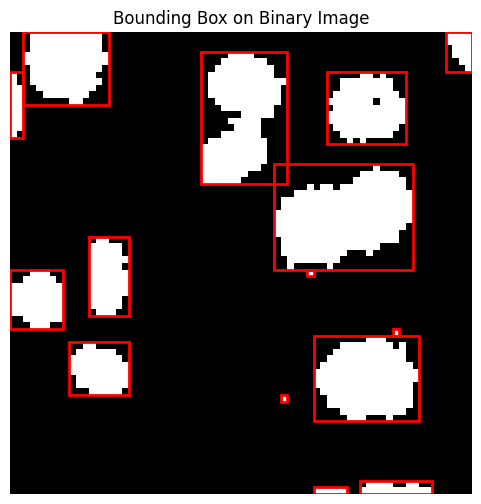

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray')
ax.set_title('Bounding Box on Binary Image')

for region in regions:
    # Get the bounding box coordinates (min_row, min_col, max_row, max_col)
    min_row, min_col, max_row, max_col = region.bbox

    # Correct starting position to (min_col, min_row)
    # Rectangle format: (x, y) for top-left corner, width, and height
    rect = plt.Rectangle(
        (min_col-0.5, min_row-0.5),  # Correct start position (x = min_col, y = min_row)
        max_col - min_col,  # Width
        max_row - min_row,  # Height
        edgecolor='red',
        facecolor='none',
        linewidth=2
    )
    ax.add_patch(rect)

plt.axis('off')
plt.show()

## Centroid

In [ ]:
from skimage.measure import centroid

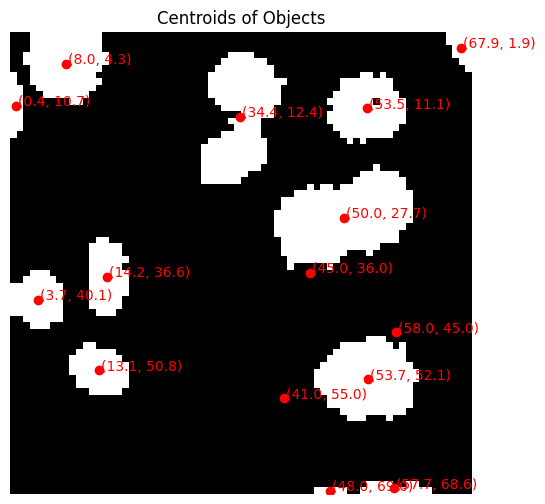

In [ ]:
# Display the centroids
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray', interpolation='none')
ax.set_title('Centroids of Objects')

for region in regions:
    # Get the centroid of the region
    centroid_y, centroid_x = region.centroid

    # Mark the centroid on the image
    ax.plot(centroid_x, centroid_y, 'ro')  # 'ro' means red circle
    ax.text(centroid_x+0.3 , centroid_y, f'({centroid_x:.1f}, {centroid_y:.1f})',
            color='red', fontsize=10)

plt.axis('off')
plt.show()

## Eccentricity (ความรี)

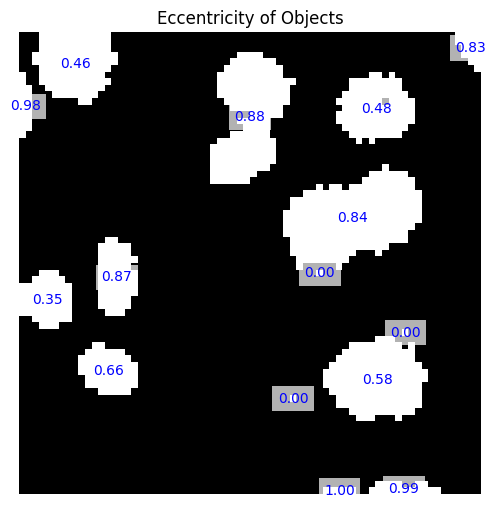

In [ ]:
# Display eccentricity values
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray', interpolation='none')
ax.set_title('Eccentricity of Objects')

for region in regions:
    # Get the centroid and eccentricity of the region
    centroid_y, centroid_x = region.centroid
    eccentricity = region.eccentricity

    # Annotate the eccentricity at the centroid of the object
    ax.text(
        centroid_x, centroid_y, f'{eccentricity:.2f}',
        color='blue', fontsize=10, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )

plt.axis('off')
plt.show()

## Solidity

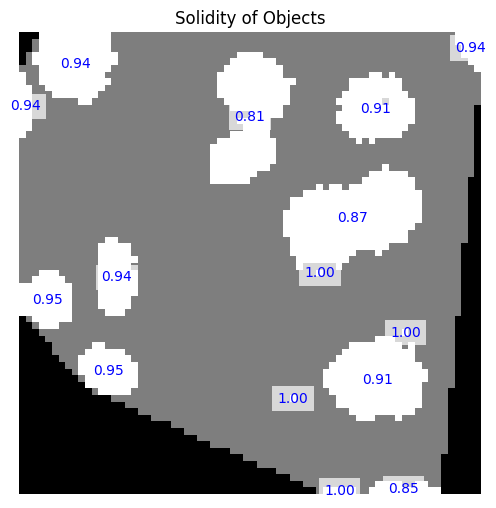

Solidity is =  1.0


In [ ]:
from skimage.morphology import convex_hull_image

# Step 4.1: Compute the convex hull of the labeled regions
convex_hull = convex_hull_image(image_cells_binary)

# Step 4.2: Display solidity values
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray', interpolation='none')
ax.set_title('Solidity of Objects')

for region in regions:
    # Get the centroid and solidity of the region
    centroid_y, centroid_x = region.centroid
    solidity = region.solidity

    # Annotate the solidity value on the image
    ax.text(
        centroid_x, centroid_y, f'{solidity:.2f}',
        color='blue', fontsize=10, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )
# Overlay the convex hull in gray
ax.imshow(convex_hull, cmap='gray', interpolation='none', alpha=0.5)
plt.axis('off')
plt.show()

print("Solidity is = ",solidity)